# `Maranatha.jl` :: Multi-Run Merge and Report Workflow

This notebook demonstrates a more advanced practical workflow in
which a nontrivial multidimensional integral is evaluated across
multiple separate runs, merged into a single dataset, and then
reported using the high-level tools provided by `Maranatha.jl`.

This workflow is useful when:

- a full resolution range is easier to compute in multiple batches,
- different `nsamples` are generated in separate sessions,
- you want to merge saved result files into one dataset,
- you want to inspect and document the merged datapoints before fitting,
- you want to produce both datapoints-only and fit-aware internal notes.

The overall workflow is:

1. Configure the numerical experiment
2. Run the quadrature study in multiple batches
3. Merge the saved result files
4. Load the merged dataset
5. Inspect and report the merged datapoints
6. Perform least-chi-square fitting
7. Produce fit-aware plots and final internal notes

## Initialize Julia environment

First we configure the Julia runtime and load the
**`Maranatha.jl`** package.

In [1]:
ENV["JULIA_NUM_THREADS"] = get(ENV, "JULIA_NUM_THREADS", "4")

using Maranatha

## Load the integrand and define the experiment

We now load a more realistic multidimensional integrand and specify
the numerical setup used throughout this notebook.

Compared with simpler pedagogical examples, this case is closer to
a genuine research workflow:

- the integrand is nontrivial,
- the dimension is higher,
- threading is enabled,
- and the full resolution range will be assembled from multiple runs.

This makes the example useful as a template for practical usage.

In [2]:
include("../scripts/experiments/integrand_Z_q.jl")

ff(x1,x2,x3,x4) = integrand_Z_q((x1,x2,x3,x4))

# bounds=(0.0,π)
bounds=(0.0, 3.141592653589793)
use_threads = true
dim = 4
rule = :gauss_p2
boundary = :LU_EXEX
err_method = :forwarddiff # :forwarddiff , :taylorseries , :enzyme , :fastdifferentiation
nerr_terms = 3
ff_shift = 0
fit_terms = 4
result_string = "Z_q_ForwardDiff"
save_path = "jld2"
write_summary = true
save_file=true

true

## Run the quadrature study in separate batches

Instead of computing the entire resolution range in a single call,
we split the experiment into multiple runs.

This can be useful when:

- you want finer control over compute time,
- different subsets of `nsamples` are generated separately,
- long runs are easier to manage in chunks,
- or results are accumulated incrementally over time.

Each batch will save a separate result file, which we will merge later.

Typical runtime on a consumer-grade machine (e.g., a 2022 M2 MacBook Air):

```text
238.729795 seconds (257.60 M allocations: 9.745 GiB, 1.88% gc time, 72.35% compilation time: <1% of which was recompilation)
```
The first run is often significantly slower because Julia must
compile many methods before executing the actual quadrature.

Precomputed result files are provided so that users who only wish to
explore the later stages of the workflow can proceed immediately.
Those interested in reproducing the full computation can run the
experiment themselves using the timing above as a rough reference.

In [3]:
#= ns = [2]
ns .+= 20

@time run_result = run_Maranatha(
    ff, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method,
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms,
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
) =#

## Second batch

We now compute the next resolution block and save it as a separate result.

Keeping batches separate at this stage makes it easier to rerun only
part of the workflow if one resolution range needs to be replaced or extended.

Typical runtime after compilation on a consumer-grade machine
(e.g., a 2022 M2 MacBook Air):

```text
75.298137 seconds (24.53 M allocations: 831.842 MiB, 0.12% gc time)
```

Subsequent runs are usually much faster once the required
code paths have been compiled.

Precomputed result files are provided so that users can continue
with the workflow without repeating this step. Those interested in
reproducing the computation can run the batch themselves, using the
timing above as a rough reference.

In [4]:
#= ns = [3]
ns .+= 20

@time run_result = run_Maranatha(
    ff, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method,
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms,
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
) =#

## Final batch

This final batch completes the intended resolution range for the experiment.

After this step, we will have several compatible saved result files
that can be merged into a single dataset for downstream analysis.

Typical runtime for the largest resolution block on a consumer-grade machine
(e.g., a 2022 M2 MacBook Air):

```text
714.671883 seconds (227.91 M allocations: 7.547 GiB, 0.10% gc time)
```

Larger `nsamples` generally increase the computational cost
substantially, especially for multidimensional integrals.

As with the earlier batches, precomputed result files are provided so that
users can proceed directly to the merging and analysis stages without
re-running this expensive step. Users who wish to reproduce the full
experiment can execute the computation themselves, using the timing above
as a rough reference.

In [5]:
#= ns = [4,5,6,7,8,9]
ns .+= 20

@time run_result = run_Maranatha(
    ff, 
    bounds...; 
    dim=dim, 
    nsamples=ns,
    rule=rule, 
    boundary=boundary, 
    err_method=err_method,
    fit_terms=fit_terms, 
    nerr_terms=nerr_terms,
    ff_shift=ff_shift, 
    use_threads=use_threads,
    name_prefix=result_string,
    save_path=save_path,
    write_summary=write_summary  
) =#

## Merge the saved result files

Now we combine the separately generated result files into one merged dataset.

This step checks that the saved runs are compatible and then concatenates
their datapoints into a single result object stored on disk.

The merged dataset is more convenient for later stages such as:

- datapoint inspection,
- reporting,
- fitting,
- and final internal-note generation.

In [6]:
base = "jld2"

merged_file = merge_datapoint_result_files(
    joinpath(base, "result_$(result_string)_$(rule)_$(boundary)_N_22.jld2"),
    joinpath(base, "result_$(result_string)_$(rule)_$(boundary)_N_23.jld2"),
    joinpath(base, "result_$(result_string)_$(rule)_$(boundary)_N_24_25_26_27_28_29.jld2");
    output_path = joinpath(base,
        "result_$(result_string)_$(rule)_$(boundary)_N_22_23_24_25_26_27_28_29.jld2"
    ),
    write_summary = true
)

"jld2/result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29.jld2"

## Load the merged dataset

After merging, we load the combined result back into memory.

From this point onward, the workflow proceeds as if the full dataset
had been generated in a single run, even though it was assembled from
multiple saved result blocks.

In [7]:
run_result = load_datapoint_results(merged_file)

(a = 0.0, b = 3.141592653589793, h = [0.14279966607226333, 0.13659098493868665, 0.1308996938995747, 0.12566370614359174, 0.1208304866765305, 0.11635528346628864, 0.1121997376282069, 0.10833078115826873], avg = [0.774558717791704, 0.774491544123877, 0.7744325915149394, 0.774380571146774, 0.7743344372197447, 0.7742933339670139, 0.7742565556695241, 0.7742235161603198], err = [(ks = [4, 5, 6], coeffs = [0.00509259259342798, 6.063298011819521e-13, 0.10253894767956809], derivatives = [1.8281569957648571, 14.149935361316306, -37.659657683379045], terms = [5.528259006545674e-7, 7.274891517869103e-17, -4.675796131330261e-6], total = -4.122970230602945e-6, center = (1.5707963267948966, 1.5707963267948966, 1.5707963267948966, 1.5707963267948966), h = 0.14279966607226333), (ks = [4, 5, 6], coeffs = [0.005324074075057675, 1.2126596023639043e-13, 0.11718244782597241], derivatives = [1.8281569957647854, 14.149935361315668, -37.65965768337212], terms = [4.6277273232447266e-7, 1.1143601831666318e-17, -

## Construct a file-style dataset label

For the reporting tools, it is convenient to associate the merged
dataset with a stable filename-style identifier.

This string will be reused when generating plots and report artifacts,
so that the saved outputs remain easy to trace back to the merged result file.

In [8]:
save_path = "."
run_result_file = joinpath(
    save_path,
    merged_file
)

"./jld2/result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29.jld2"

## Inspect the merged datapoints

Before fitting, we inspect the merged dataset directly.

This helps verify that the combined resolution range behaves as expected
after merging and that the transformed horizontal coordinate provides
a sensible view of the convergence pattern.

In particular, this plot is useful for checking

- whether the merged points line up smoothly,
- whether the error bars look reasonable,
- and whether the chosen resolution range appears suitable for fitting.

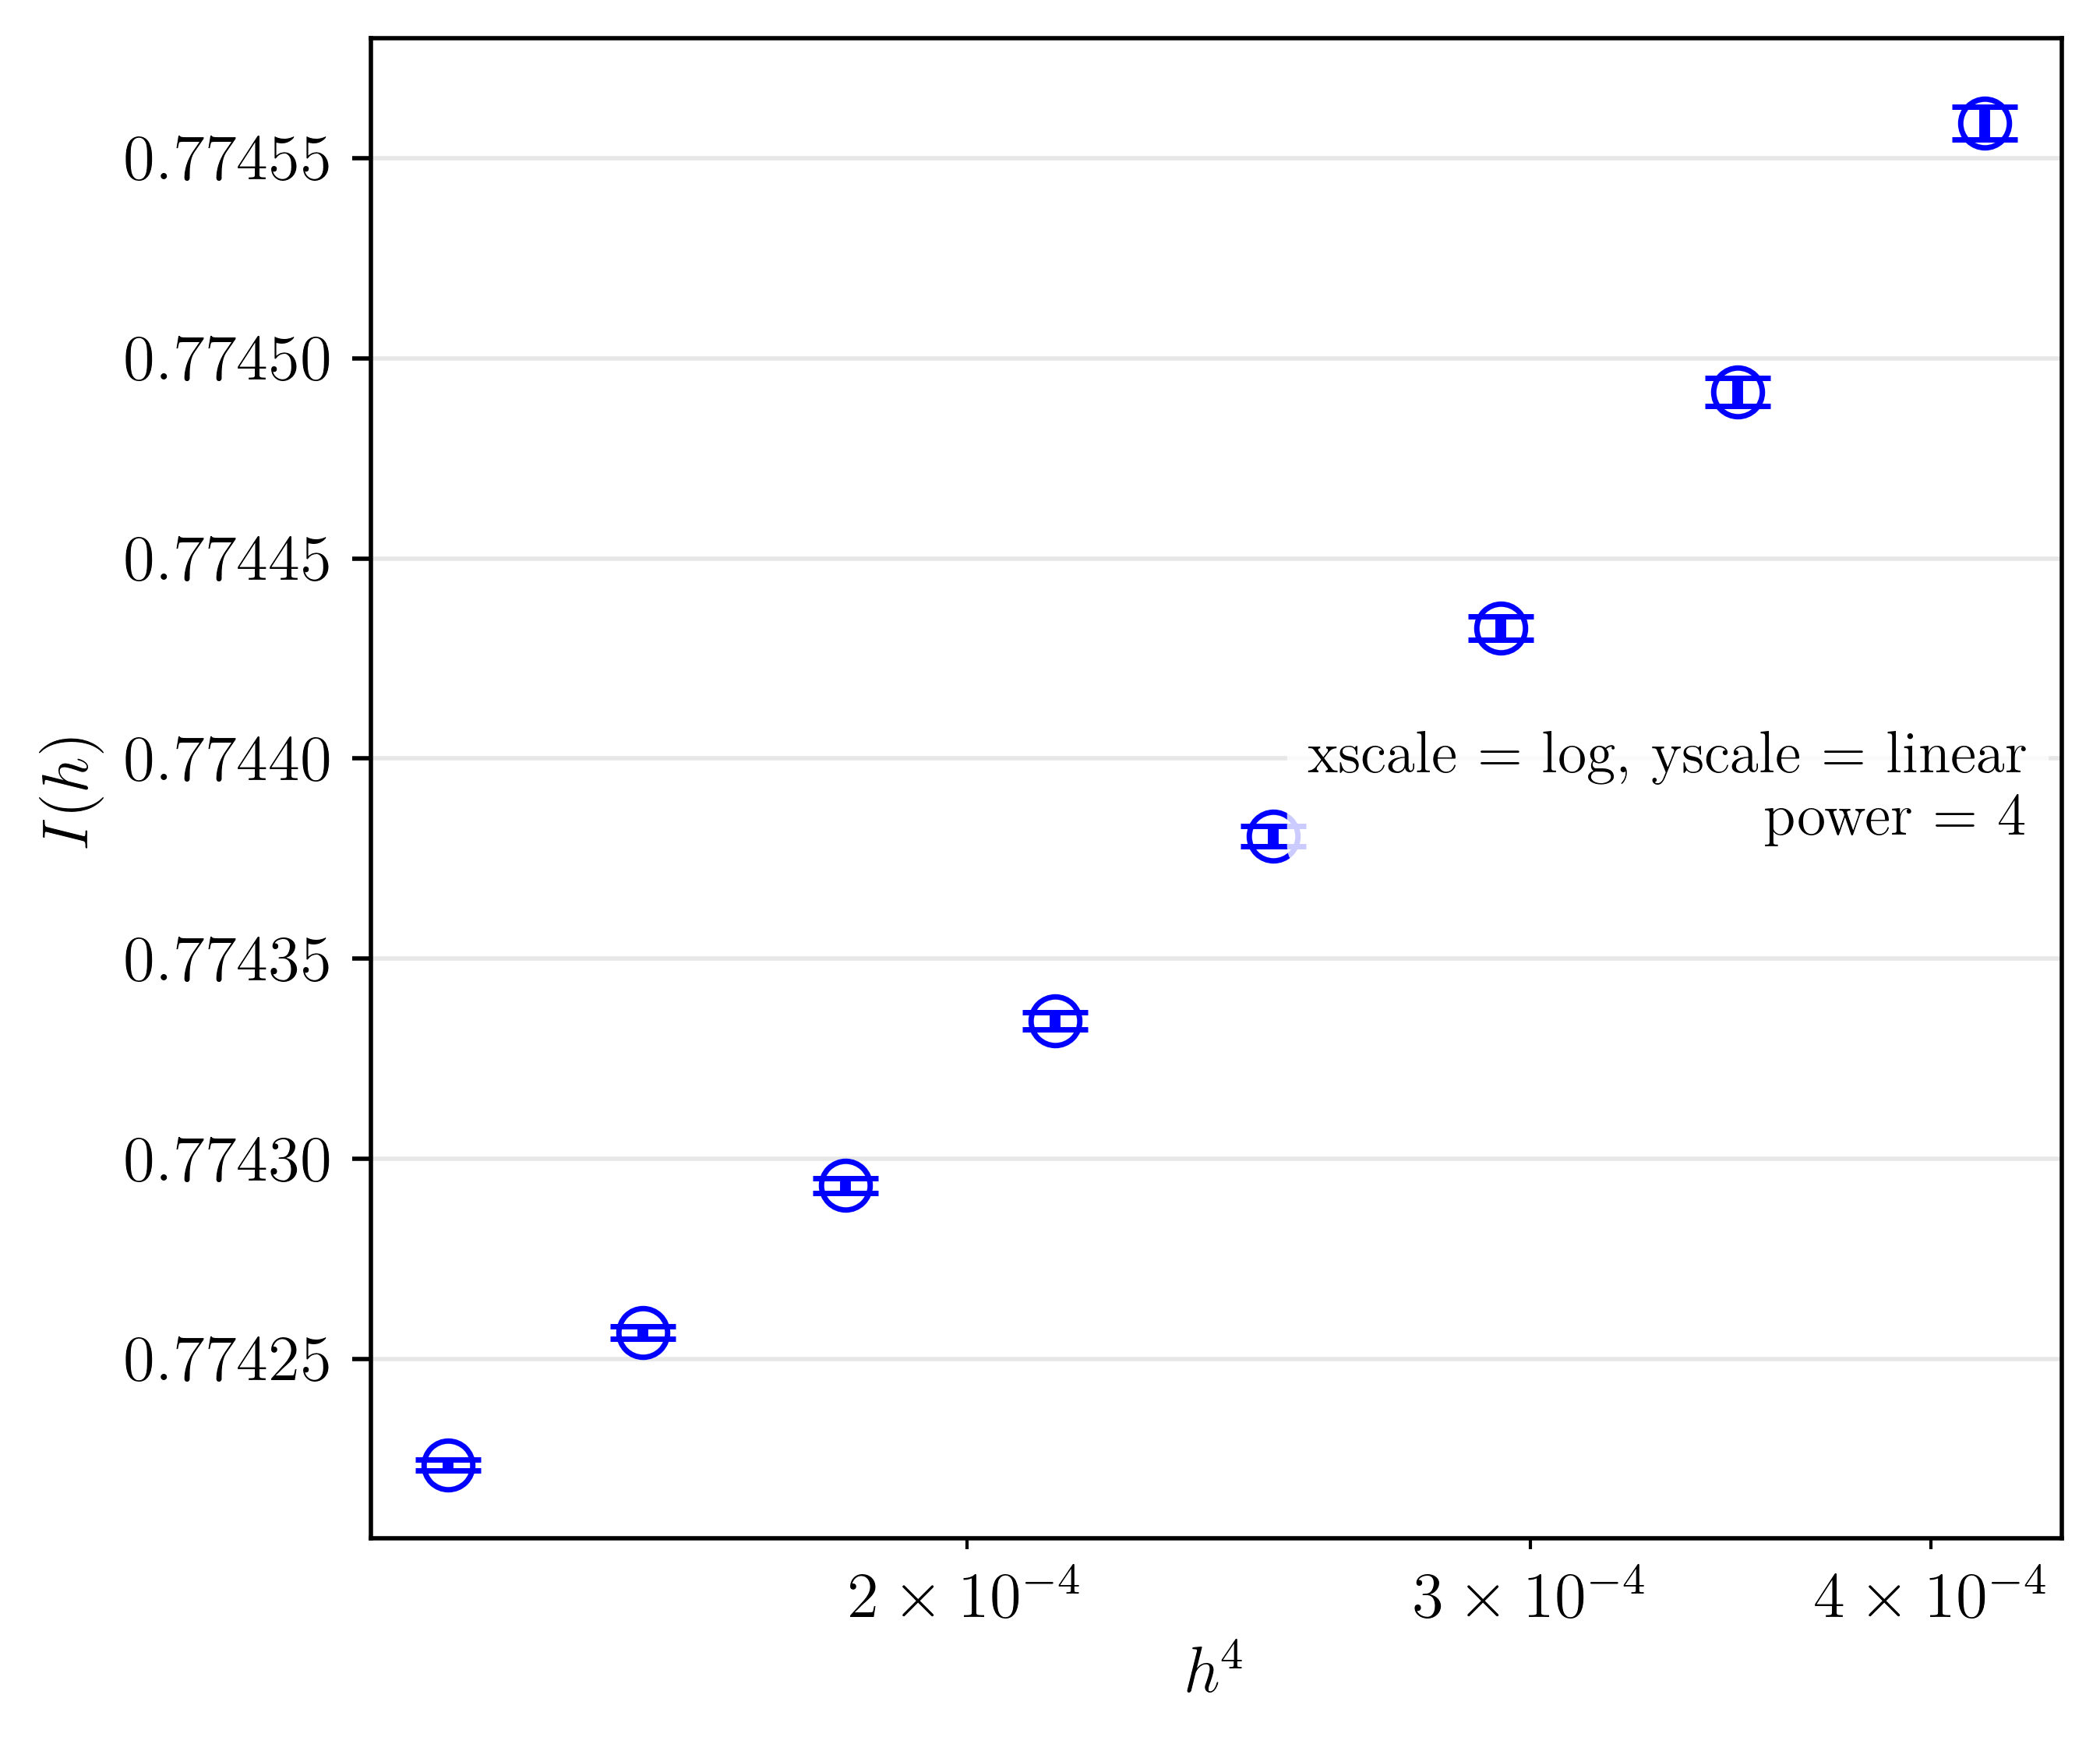

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_gauss_p2_LU_EXEX_datapoints_hpow_4_log_linear-crop.pdf'.


In [9]:
h_power = 4
xscale = :log
yscale = :linear

plot_datapoints_result(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    save_file = true
)

## Generate a datapoints-only internal note for the merged dataset

Before performing the fit, we create a standalone internal note
documenting the merged raw datapoints.

This note records the pre-fit state of the experiment and includes:

- the datapoints-only summary table,
- the saved datapoints plot,
- a REVTeX-based master document,
- and a reproducible build structure.

Such a note is useful when the merged dataset itself should be archived
or reviewed independently of the final extrapolation.

In [10]:
note_info = write_convergence_internal_note_datapoints(
    run_result;
    name = run_result_file,
    h_power = h_power,
    xscale = xscale,
    yscale = yscale,
    rule = run_result.rule,
    boundary = run_result.boundary,
    out_dir = ".",
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
)

pdflatex inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode

(./inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28
_29_hpow_4_log_linear.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/usr/local/te

(note_dir = "./inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear", figs_dir = "./inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/figs", summary_tex_path = "./inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear_table.tex", fig_tex_path = "./inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear_figs.tex", master_tex_path = "./inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear/inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_hpow_4_log_linear.tex", makefile_path = "./inote_summary_result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_N_22_23_24_25_26_27_28_29_h

## Perform the continuum extrapolation on the merged dataset

With the merged dataset inspected and documented, we now carry out
the least-chi-square fit.

This step converts the raw convergence data into a model-based
continuum extrapolation, yielding

- fitted parameters,
- the extrapolated value,
- uncertainty information,
- and goodness-of-fit diagnostics.

In [11]:
fit_result = least_chi_square_fit(
    run_result; 
    nterms=4, 
    ff_shift=0, 
    nerr_terms=3
)

[2026-03-14 09:04:38.924] residual ks (backend) = [4, 5, 6, 7], fit powers (h^p), ff_shift=0 = [4, 5, 6]


(estimate = 0.7738866703221303, error_estimate = 7.760744943255801e-5, params = [0.7738866703221303, 7.550881777946219, -64.61236009868986, 161.44072203499218], param_errors = [7.760744943255801e-5, 5.029939469554763, 64.57145803651453, 214.95622206215162], cov = [6.02291620742705e-9 -0.00038847897006156237 0.0049734341076796695 -0.016501638084042595; -0.00038847897006168413 25.300291067384844 -324.68868687235073 1079.8689278688587; 0.004973434107681621 -324.6886868723766 4169.473192961356 -13875.72046016052; -0.016501638084050373 1079.8689278690274 -13875.720460161587 46206.17740323304], powers = [0, 4, 5, 6], chisq = 0.002684627774348073, redchisq = 0.0006711569435870182, dof = 4)

## Inspect the fit result

We print the fit result to examine the extrapolated value and the
associated parameter estimates before moving on to the final plots
and report-generation stage.

In [12]:
print_fit_result(fit_result)

[2026-03-14 09:04:40.309]            λ_0 = 0.773887(78)
[2026-03-14 09:04:40.310]            λ_1 = 7.6(50)
[2026-03-14 09:04:40.357]            λ_2 = -65(65)
[2026-03-14 09:04:40.357]            λ_3 = 161(215) *
[2026-03-14 09:04:40.358] 
[2026-03-14 09:04:40.358] Chi^2 / d.o.f. = 2.684627774348e-03 / 4 = 6.711569435870e-04
[2026-03-14 09:04:40.358] Result (h→0)   = 0.773887(78)
[2026-03-14 09:04:40.358] 


## Visualize the fitted convergence behavior

Next we generate the standard fit-aware convergence plots.

These visualizations combine the original datapoints with the fitted model,
its uncertainty band, and the extrapolated limit, making it easier to
interpret the behavior of the merged dataset after fitting.

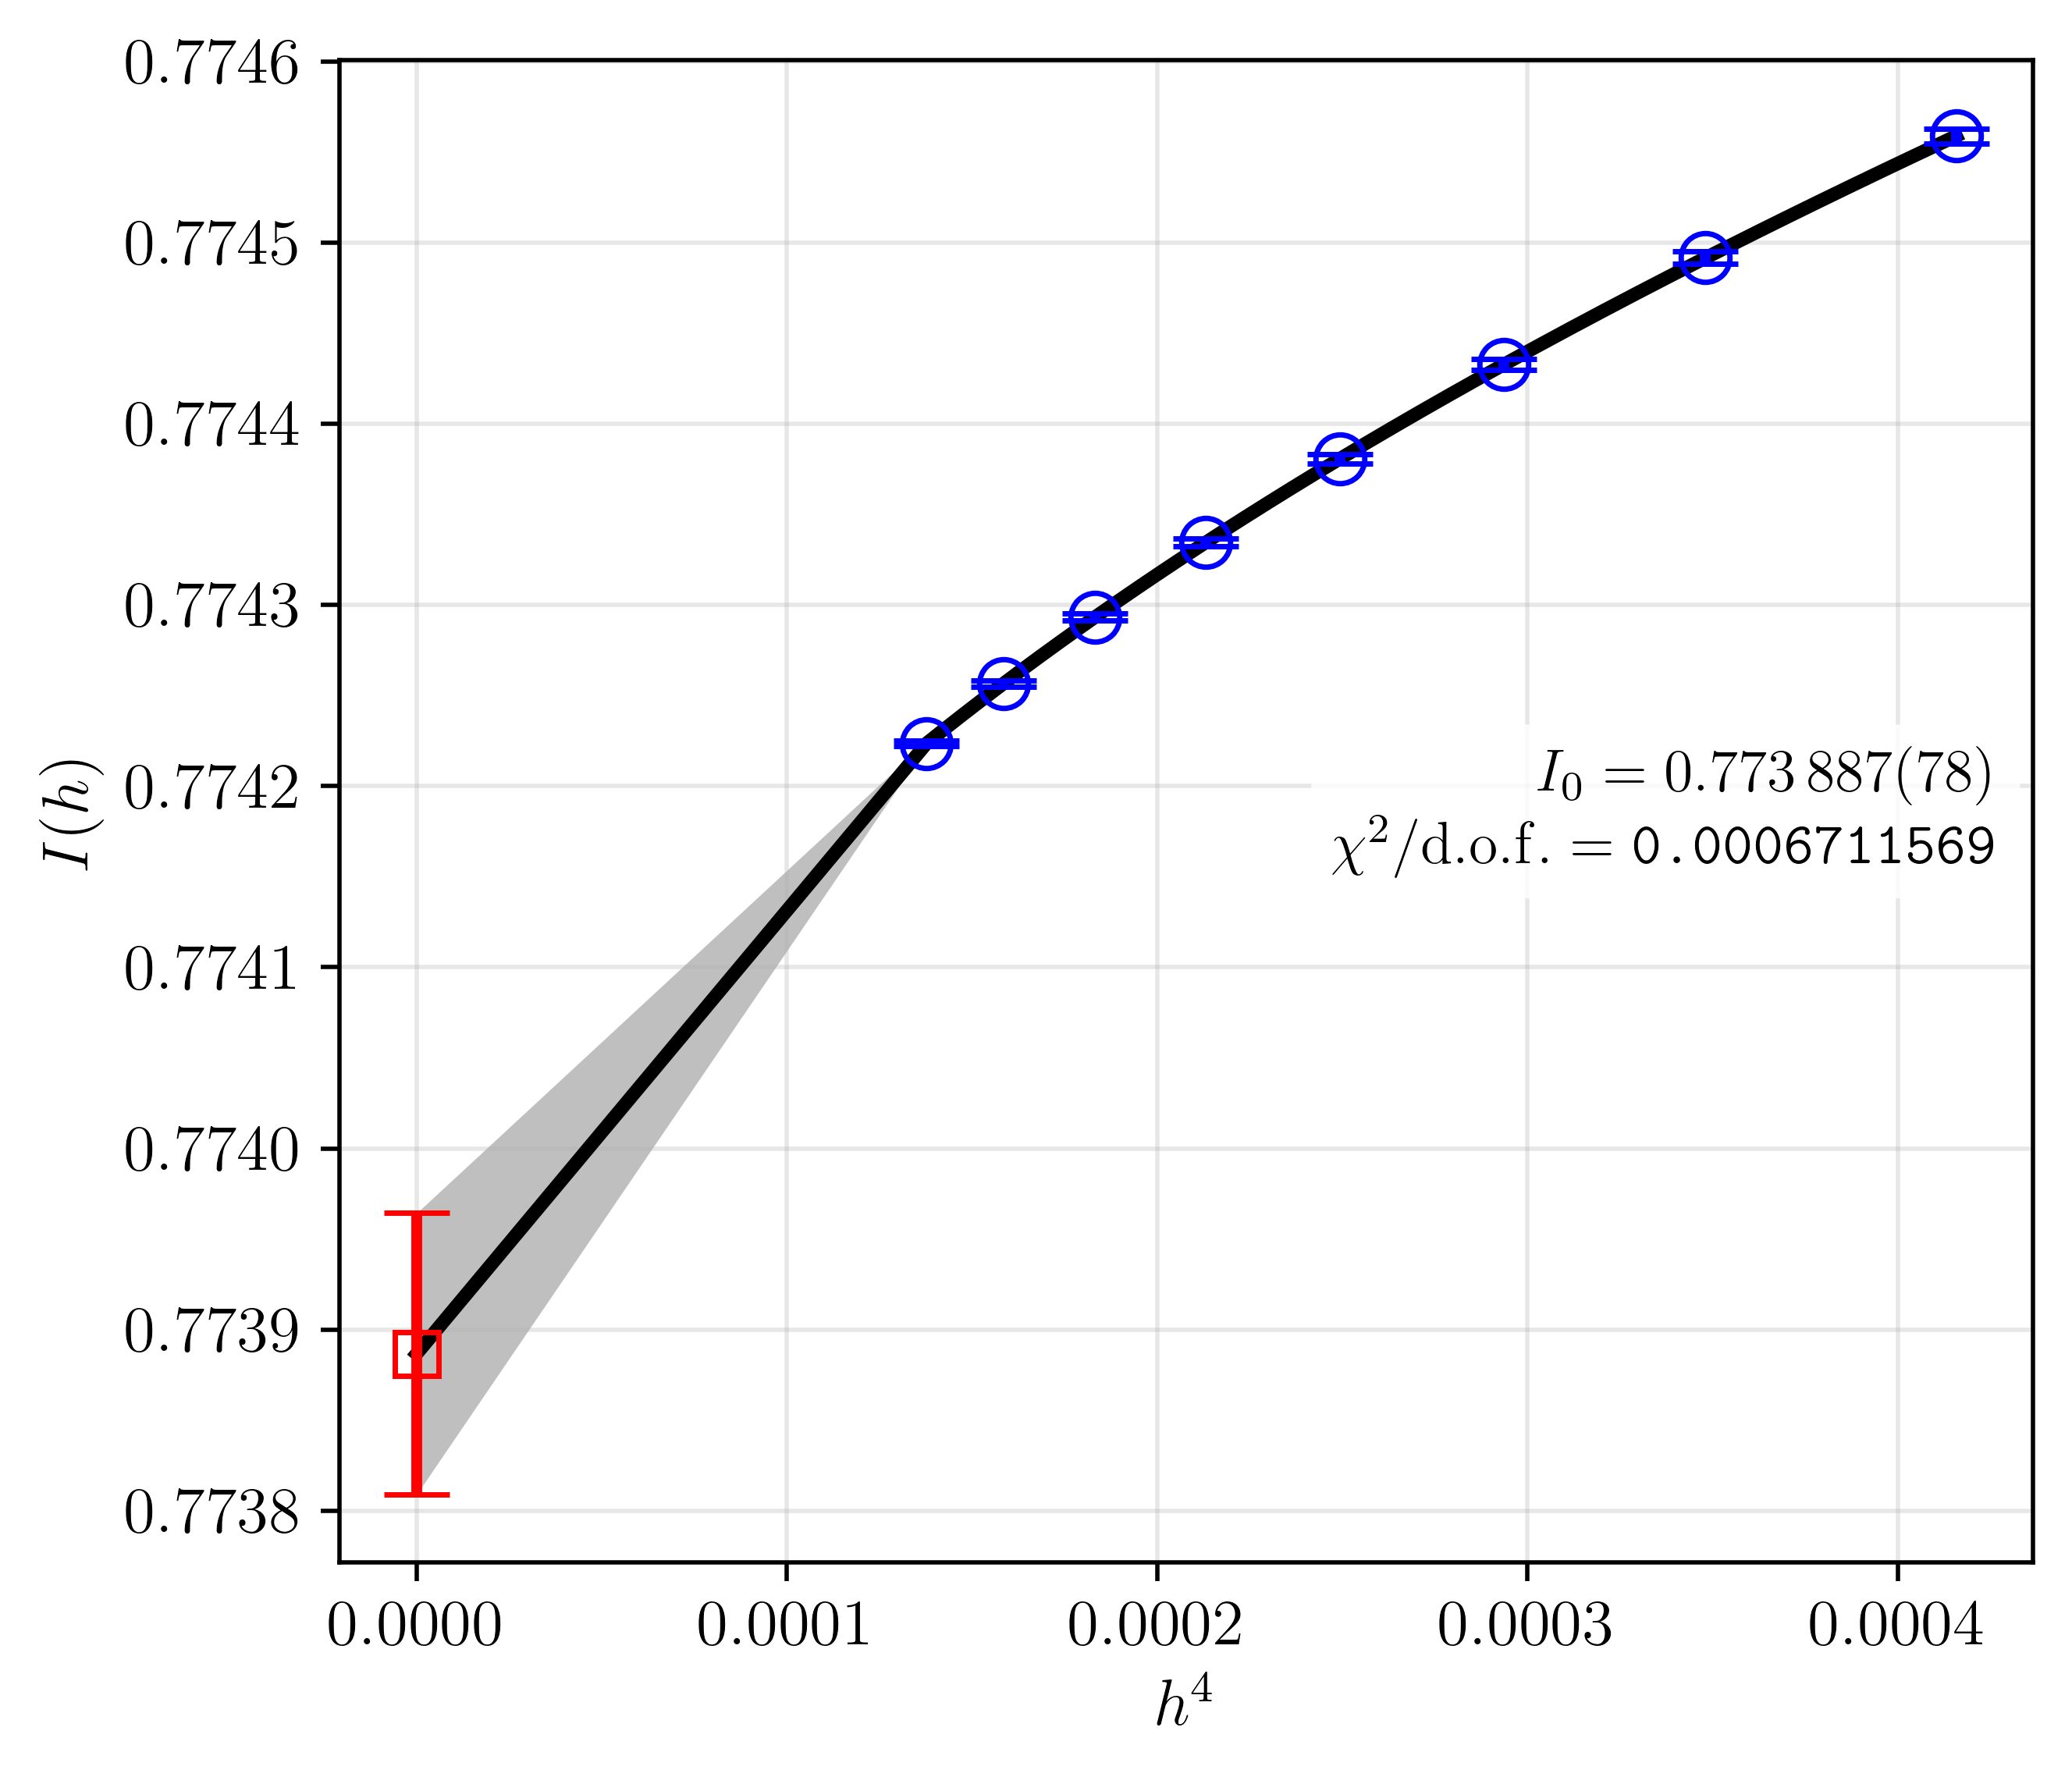

PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_extrap-crop.pdf'.
PDFCROP 1.42, 2023/04/15 - Copyright (c) 2002-2023 by Heiko Oberdiek, Oberdiek Package Support Group.
==> 1 page written on `./result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_reldiff-crop.pdf'.


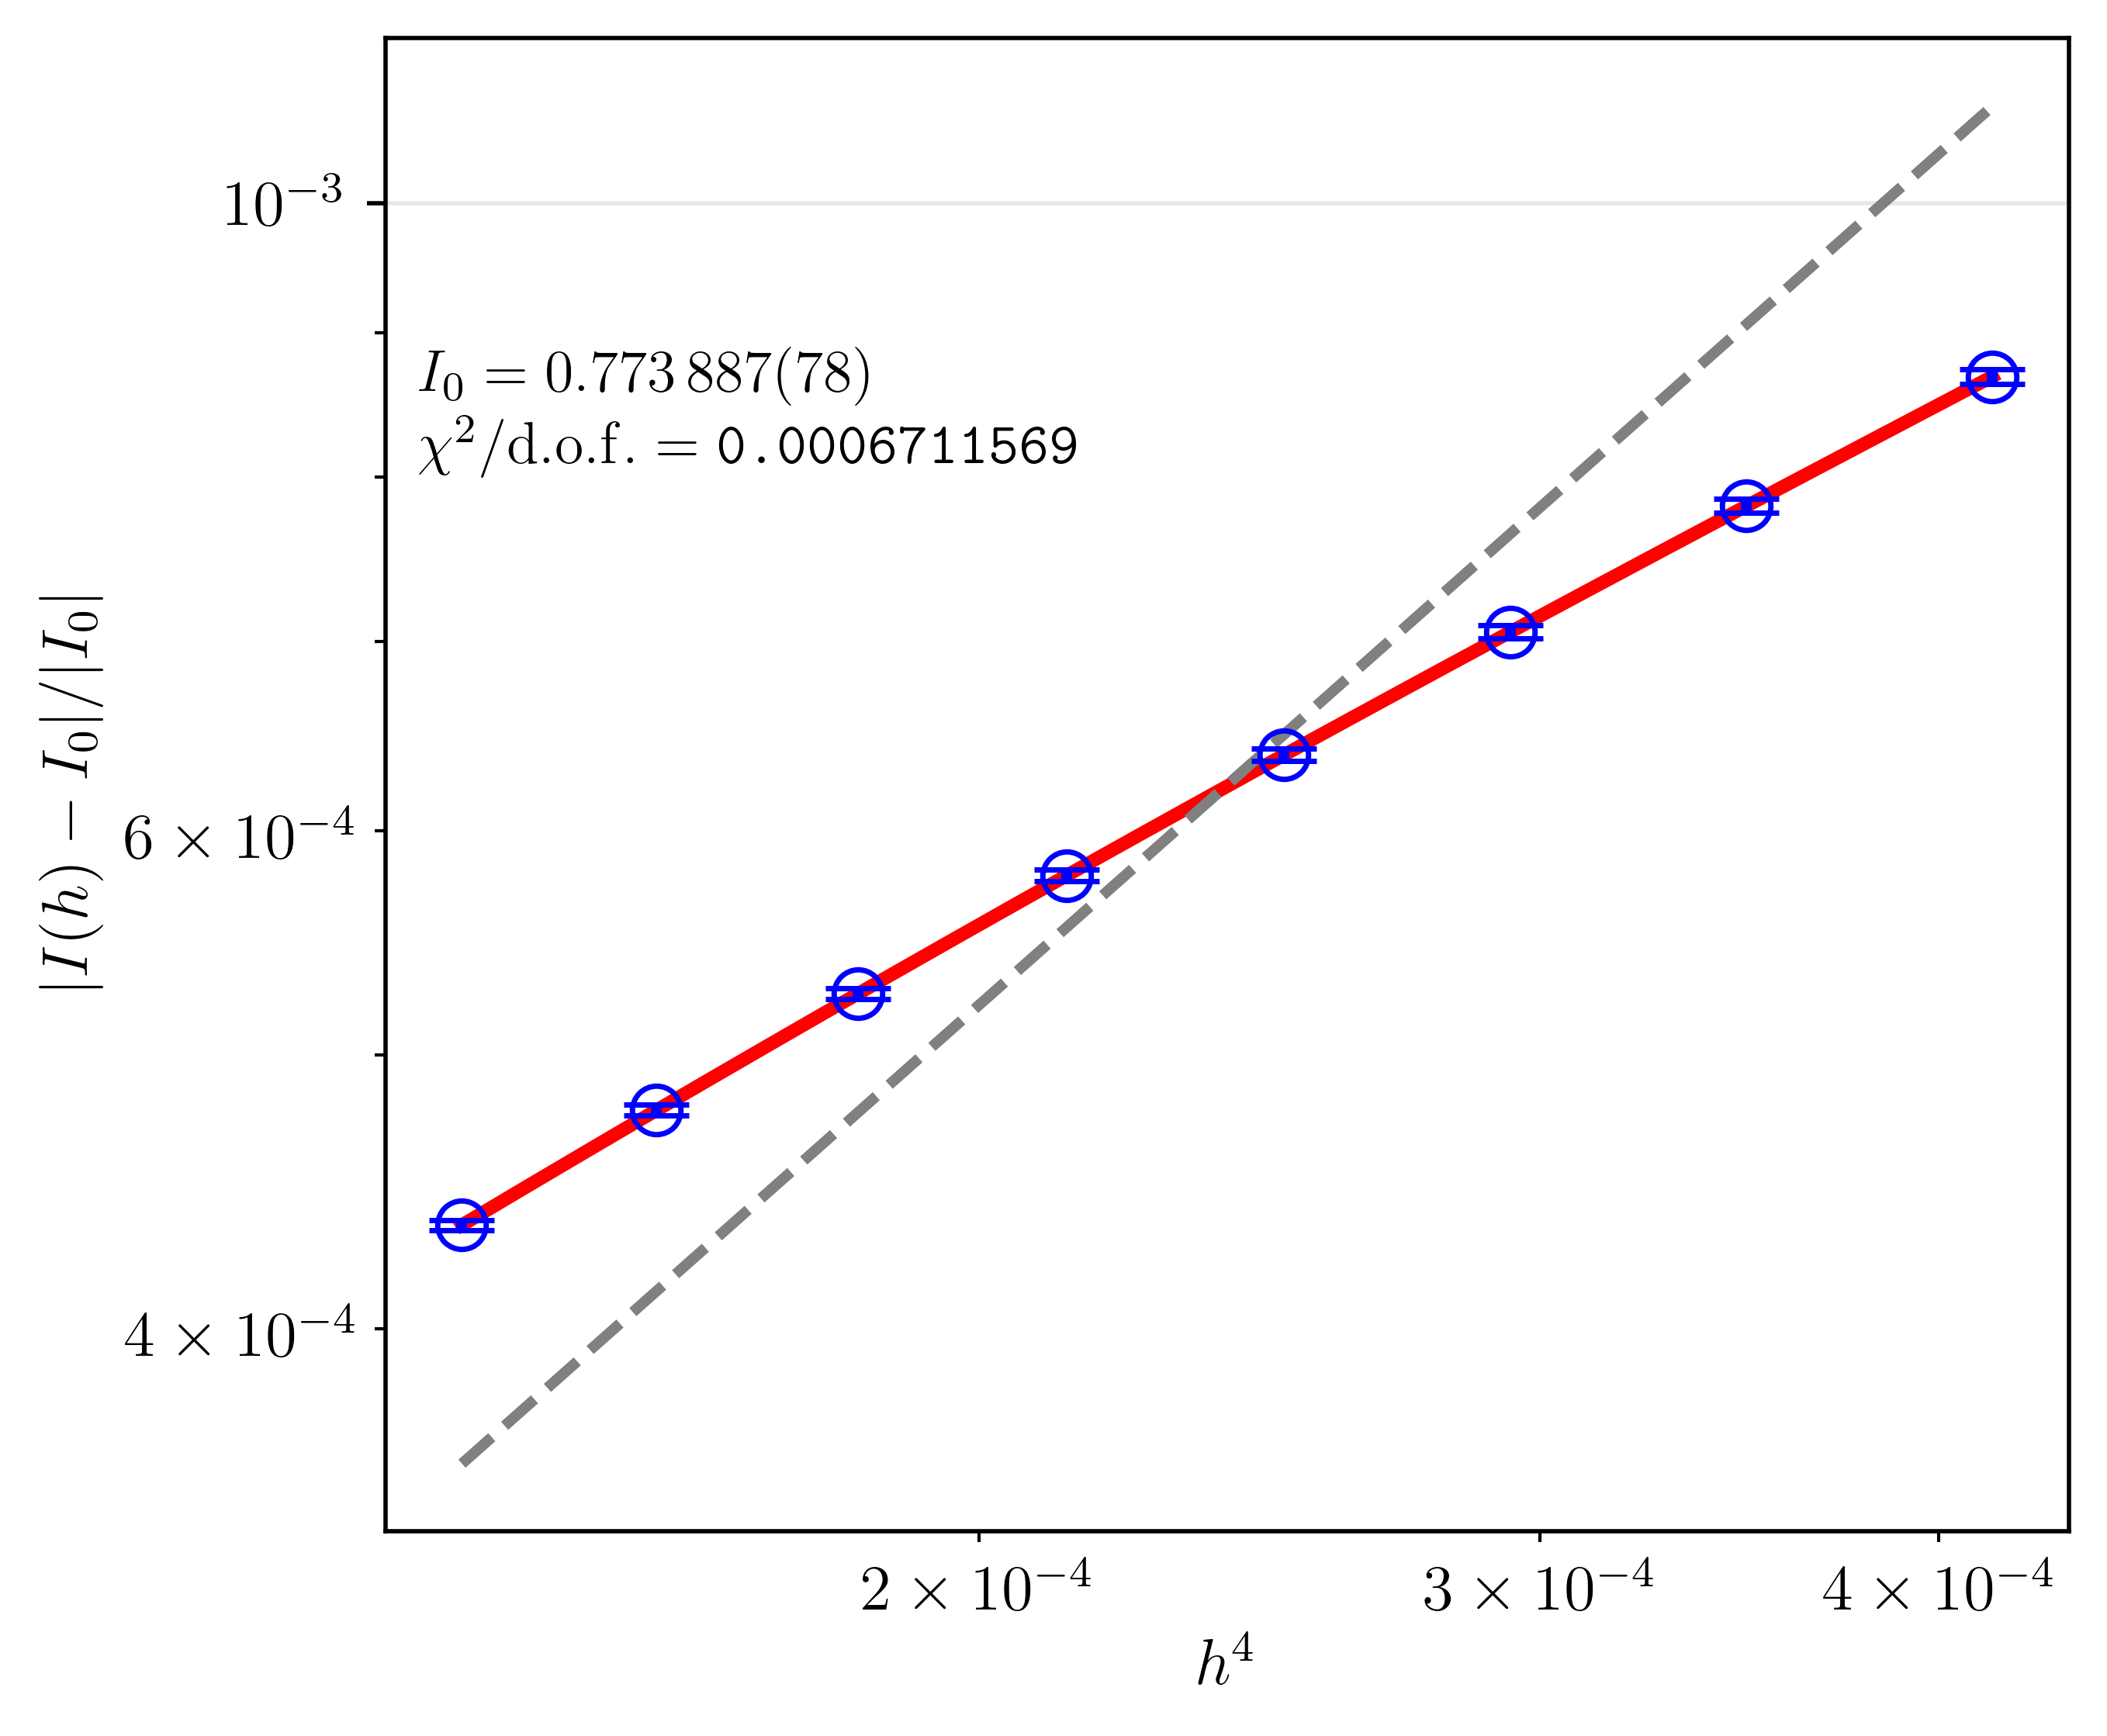

In [13]:
plot_convergence_result(
    run_result, 
    fit_result;
    name=result_string,
    figs_dir=".",
    save_file=true
)

## Generate the final fit-aware internal note

Finally, we build the full internal note for the fitted analysis.

This note complements the earlier datapoints-only note by including
the fit-aware convergence summary and the final convergence figures.

Together, the two notes document both:

- the raw merged dataset before fitting, and
- the final extrapolated analysis after fitting.

In [14]:
note_info = write_convergence_internal_note(
    run_result,
    fit_result;
    name = result_string,
    rule = run_result.rule,
    boundary = run_result.boundary,
    out_dir = ".",
    save_file = true,
    try_build_pdf = true,
    move_existing_plots = true,
    # author = "Benjamin J. Choi",
    # affiliation = "Center for Computational Sciences, University of Tsukuba, 1-1-1 Tennodai, Tsukuba, Ibaraki 305-8577, Japan",
    # abstract_text = "This note summarizes the convergence study and fitted extrapolation result."
)

pdflatex inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3
This is pdfTeX, Version 3.141592653-2.6-1.40.28 (TeX Live 2025) (preloaded format=pdflatex)
 restricted \write18 enabled.
entering extended mode
(./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3.tex
LaTeX2e <2025-11-01>
L3 programming layer <2026-01-19>
(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/revtex4-2.cls
Document Class: revtex4-2 2022/06/05 4.2f (https://journals.aps.org/revtex/ for
 documentation)
ltxutil[2022/06/05 4.2f utilities package (portions licensed from W. E. Baxter 
web at superscript.com)]
ltxfront[2022/06/05 4.2f frontmatter package (AO,DPC,MD)]
ltxgrid[2022/06/05 4.2f page grid package (portions licensed from W. E. Baxter 
web at superscript.com)]

Class revtex4-2 Warning: No Society specified, using default society aps.

(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/aps4-2.rtx)
(/usr/local/texlive/2025/texmf-dist/tex/latex/revtex/aps12pt4-2.rtx)
(/usr/local/texlive/2025/texm

(note_dir = "./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3", figs_dir = "./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3/figs", summary_tex_path = "./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3/summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3_table.tex", fig_tex_path = "./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3/summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3_figs.tex", master_tex_path = "./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3/inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3.tex", makefile_path = "./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3/Makefile", moved_plots = ["./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3/figs/result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_extrap.pdf", "./inote_summary_Z_q_ForwardDiff_gauss_p2_LU_EXEX_ff_4_er_3/figs/result_Z_q_ForwardDiff_gauss_p2_LU_EXEX_reldiff.pdf"], missing_plots = String[], build_attempted = true, build_succeeded = true, build_message 

## Summary

In this notebook we demonstrated a practical multi-run workflow for
building and analyzing a merged quadrature dataset in `Maranatha.jl`.

Workflow:

1. Define a realistic multidimensional numerical experiment
2. Run several compatible batches of `nsamples`
3. Save the partial result files
4. Merge them into a single dataset
5. Inspect the merged datapoints
6. Generate a datapoints-only internal note
7. Perform least-chi-square fitting
8. Visualize the fitted convergence result
9. Generate the final fit-aware internal note

This workflow is especially useful when

- a full study is accumulated incrementally,
- runs are naturally split across multiple sessions,
- merged datasets need to be archived before fitting,
- and both pre-fit and post-fit reporting artifacts are desired.